# 05 — Modélisation SARIMA / SARIMAX et Prophet

## Projet : Smart City Energy Forecasting — Tetouan

Ce notebook correspond à la première phase de modélisation après le feature engineering.

Objectifs :

- charger le dataset enrichi `tetouan_features.csv` ;
- charger les baselines naïves calculées dans le notebook 04 ;
- créer un split chronologique train / validation / test ;
- entraîner un modèle SARIMA univarié ;
- entraîner un modèle SARIMAX avec variables exogènes ;
- entraîner un modèle Prophet avec régresseurs météo/calendaires ;
- comparer les performances avec les baselines naïves ;
- sauvegarder les métriques, prédictions et figures.

Les modèles ML tabulaires, comme Random Forest et XGBoost, seront traités dans le notebook suivant `06_modeling_ml_xgboost.ipynb`.

## 1. Imports et chemins du projet

Le notebook utilise :

- `src/models_sarima.py` pour SARIMA / SARIMAX ;
- `src/models_prophet.py` pour Prophet ;
- `src/models_baseline.py` pour le split temporel.

In [22]:
import sys
from pathlib import Path
import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import src.models_sarima as models_sarima
import src.models_prophet as models_prophet
import src.models_baseline as models_baseline

importlib.reload(models_sarima)
importlib.reload(models_prophet)
importlib.reload(models_baseline)

from src.models_baseline import temporal_train_val_test_split
from src.models_sarima import (
    DEFAULT_SARIMAX_EXOG_COLS,
    SarimaConfig,
    run_sarima_experiment,
    select_available_columns as select_sarima_available_columns,
)
from src.models_prophet import (
    DEFAULT_PROPHET_REGRESSORS,
    ProphetConfig,
    make_prophet_holidays,
    run_prophet_experiment,
    select_available_columns as select_prophet_available_columns,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "tetouan_features.csv"
FEATURE_COLUMNS_PATH = PROJECT_ROOT / "data" / "processed" / "feature_columns.txt"

BASELINE_METRICS_PATH = PROJECT_ROOT / "results" / "metrics" / "baseline_naive_metrics.csv"

RESULTS_METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
RESULTS_PRED_DIR = PROJECT_ROOT / "results" / "predictions"
RESULTS_FIG_DIR = PROJECT_ROOT / "results" / "figures"

SARIMA_PROPHET_METRICS_PATH = RESULTS_METRICS_DIR / "sarima_prophet_metrics.csv"
SARIMA_PROPHET_PRED_PATH = RESULTS_PRED_DIR / "sarima_prophet_predictions.csv"
SARIMA_PROPHET_FIG_PATH = RESULTS_FIG_DIR / "sarima_prophet_forecast_test_week.png"
SARIMA_PROPHET_FULL_FIG_PATH = RESULTS_FIG_DIR / "sarima_prophet_forecast_full_test.png"

for path in [
    RESULTS_METRICS_DIR,
    RESULTS_PRED_DIR,
    RESULTS_FIG_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

print("Racine du projet :", PROJECT_ROOT)

Racine du projet : C:\Users\Badr\UB\0_Inbox\00-projects-code\dm-pfm-project\smart-city-energy-forecasting-tetouan


## 2. Chargement du dataset features

Le dataset utilisé ici est celui produit par le notebook 04 :

`data/processed/tetouan_features.csv`

Il contient la cible `target`, les variables météo, les variables temporelles, les lags, les rolling features et les interactions.

In [23]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Fichier introuvable : {DATA_PATH}. "
        "Exécuter d'abord le notebook 04_feature_engineering.ipynb."
    )

df = pd.read_csv(DATA_PATH)

if "datetime" in df.columns:
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df = df.set_index("datetime")
else:
    first_col = df.columns[0]
    df[first_col] = pd.to_datetime(df[first_col], errors="coerce")
    df = df.set_index(first_col)
    df.index.name = "datetime"

df = df.sort_index()

if "target" not in df.columns:
    raise ValueError("La colonne cible 'target' est absente du dataset features.")

print("Dimensions du dataset features :", df.shape)
print("Période :", df.index.min(), "→", df.index.max())
print("Fréquence inférée :", pd.infer_freq(df.index))
print("Valeurs manquantes :", int(df.isna().sum().sum()))
print("Doublons temporels :", int(df.index.duplicated().sum()))

display(df.head())

Dimensions du dataset features : (8568, 111)
Période : 2017-01-08 00:00:00 → 2017-12-30 23:00:00
Fréquence inférée : h
Valeurs manquantes : 0
Doublons temporels : 0


,temperature,humidity,wind_speed,general_diffuse_flows,diffuse_flows,zone1_power,zone2_power,zone3_power,target,total_load,target_rolling_zscore,total_load_rolling_zscore,is_target_outlier,is_total_load_outlier,is_load_outlier,hour,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,is_weekend,is_business_hour,is_morning_peak,is_evening_peak,is_peak_hour,is_off_peak,is_night,season,season_code,season_autumn,season_spring,season_summer,season_winter,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos,is_holiday,is_day_before_holiday,is_day_after_holiday,days_to_nearest_holiday,target_lag_1h,target_lag_2h,target_lag_3h,target_lag_6h,target_lag_12h,target_lag_24h,target_lag_48h,target_lag_72h,target_lag_168h,target_rolling_3h_mean,target_rolling_3h_std,target_rolling_3h_min,target_rolling_3h_max,target_rolling_6h_mean,target_rolling_6h_std,target_rolling_6h_min,target_rolling_6h_max,target_rolling_12h_mean,target_rolling_12h_std,target_rolling_12h_min,target_rolling_12h_max,target_rolling_24h_mean,target_rolling_24h_std,target_rolling_24h_min,target_rolling_24h_max,target_rolling_48h_mean,target_rolling_48h_std,target_rolling_48h_min,target_rolling_48h_max,target_rolling_168h_mean,target_rolling_168h_std,target_rolling_168h_min,target_rolling_168h_max,HDD,CDD,temperature_humidity_interaction,temperature_peak_interaction,CDD_peak_interaction,HDD_peak_interaction,general_diffuse_month_interaction,diffuse_month_interaction,temperature_lag_1h,humidity_lag_1h,HDD_lag_1h,CDD_lag_1h,temperature_lag_2h,humidity_lag_2h,HDD_lag_2h,CDD_lag_2h,temperature_lag_3h,humidity_lag_3h,HDD_lag_3h,CDD_lag_3h,temperature_lag_6h,humidity_lag_6h,HDD_lag_6h,CDD_lag_6h,temperature_lag_12h,humidity_lag_12h,HDD_lag_12h,CDD_lag_12h,is_high_temperature,is_heatwave_simulated,eval_is_high_load
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2017-01-08 00:00:00,14.273333,77.916667,0.0880,0.044667,0.123667,26633.924052,17421.276597,17871.807228,26633.924052,61927.007877,0.605689,0.402583,0,0,0,0,6,8,8,1,1,1,1,0,0,0,0,1,1,winter,0,0,0,0,1,0.000000,1.000000,-0.781831,0.62349,0.0,1.0,0.137279,0.990532,0,0,0,3,31526.075950,36025.316455,39227.341773,41583.797468,34033.417720,27193.924052,27172.658228,25979.746835,29197.974683,35592.911393,3158.861021,31526.075950,39227.341773,38309.704641,3528.606271,31526.075950,41583.797468,35676.624472,3851.666111,30612.658228,41583.797468,30612.700422,6430.701095,21502.784810,41583.797468,30662.468354,6600.138307,21453.164557,42924.556962,30102.121760,6962.283109,18540.759495,43572.658227,3.726667,0.0,1112.130556,0.0,0.0,0.0,0.044667,0.123667,13.530000,78.583333,4.470000,0.0,13.023333,78.316667,4.976667,0.0,13.070000,77.166667,4.930000,0.0,13.701667,72.591667,4.298333,0.0,14.575000,67.718333,3.425000,0.0,0,0,0
2017-01-08 01:00:00,14.441667,76.616667,0.0910,0.046500,0.137000,23640.506328,15492.401215,16057.831327,23640.506328,55190.738870,1.055631,0.858605,0,0,0,1,6,8,8,1,1,1,1,0,0,0,0,1,1,winter,0,0,0,0,1,0.258819,0.965926,-0.781831,0.62349,0.0,1.0,0.137279,0.990532,0,0,0,3,26633.924052,31526.075950,36025.316455,40846.582277,33486.582277,23961.518987,23968.607595,22892.151898,24657.215190,31395.105486,3835.138221,26633.924052,36025.316455,35818.059072,5213.136547,26633.924052,40846.582277,35060.000000,4587.406453,26633.924052,41583.797468,30589.367088,6444.065618,21502.784810,41583.797468,30651.244726,6606.518215,21453.164557,42924.556962,30086.859554,6967.057111,18540.759495,43572.658227,3.558333,0.0,1106.472361,0.0,0.0,0.0,0.046500,0.137000,14.273333,77.916667,3.726667,0.0,13.530000,78.583333,4.470000,0.0,13.023333,78.316667,4.976667,0.0,11.993333,79.133333,6.006667,0.0,14.928333,61.946667,3.071667,0.0,0,0,0
2017-01-08 02:00:00,14.216667,74.183333,0.0885,0.045833,0.123667,21817.721520,14072.340427,15021.686747,21817.721520,50911.748693,1.327609,1.149841,0,0,0,2,6,8,8,1,1,1,1,0,0,0,0,1,1,winter,0,0,0,0,1,0.500000,0.866025,-0.781831,0.623

## 3. Chargement de la liste des features modèle

La liste `feature_columns.txt` n'est pas utilisée directement pour SARIMA/Prophet, car ces modèles nécessitent une sélection plus restreinte de variables.

Cependant, on la charge pour vérifier la cohérence du pipeline global.

In [24]:
if not FEATURE_COLUMNS_PATH.exists():
    raise FileNotFoundError(
        f"Fichier introuvable : {FEATURE_COLUMNS_PATH}. "
        "Exécuter d'abord le notebook 04_feature_engineering.ipynb."
    )

feature_cols = FEATURE_COLUMNS_PATH.read_text(encoding="utf-8").splitlines()
feature_cols = [col.strip() for col in feature_cols if col.strip()]

print("Nombre de features modèle chargées :", len(feature_cols))
print("Exemples :")
display(pd.DataFrame({"feature": feature_cols}).head(30))

Nombre de features modèle chargées : 98
Exemples :


,feature
0,temperature
1,humidity
2,wind_speed
3,general_diffuse_flows
4,diffuse_flows
5,hour
6,dayofweek
7,dayofmonth
8,dayofyear
9,weekofyear


## 4. Split chronologique train / validation / test

Comme il s'agit de séries temporelles, le split doit respecter l'ordre chronologique.

On garde la même logique que dans les notebooks précédents :

- 70 % train ;
- 15 % validation ;
- 15 % test.

Pour SARIMA, SARIMAX et Prophet, on entraîne sur `train + validation`, puis on évalue sur le test.

Cette stratégie permet d'utiliser la validation comme historique supplémentaire pour les premiers modèles statistiques.

In [25]:
train_df, val_df, test_df = temporal_train_val_test_split(
    df,
    train_ratio=0.70,
    val_ratio=0.15,
)

train_val_df = pd.concat([train_df, val_df], axis=0).sort_index()

print("Train :", train_df.index.min(), "→", train_df.index.max(), "|", train_df.shape)
print("Val   :", val_df.index.min(), "→", val_df.index.max(), "|", val_df.shape)
print("Test  :", test_df.index.min(), "→", test_df.index.max(), "|", test_df.shape)
print("Train + Val :", train_val_df.index.min(), "→", train_val_df.index.max(), "|", train_val_df.shape)

assert train_df.index.max() < val_df.index.min()
assert val_df.index.max() < test_df.index.min()

print("\nSplit chronologique valide.")

Train : 2017-01-08 00:00:00 → 2017-09-14 20:00:00 | (5997, 111)
Val   : 2017-09-14 21:00:00 → 2017-11-07 09:00:00 | (1285, 111)
Test  : 2017-11-07 10:00:00 → 2017-12-30 23:00:00 | (1286, 111)
Train + Val : 2017-01-08 00:00:00 → 2017-11-07 09:00:00 | (7282, 111)

Split chronologique valide.


## 5. Rappel des baselines naïves

Les modèles SARIMA/SARIMAX/Prophet doivent être comparés à la meilleure baseline naïve.

Dans le notebook 04, la baseline la plus forte était généralement `naive_previous_week`, car la série possède une saisonnalité hebdomadaire très marquée.

In [26]:
if BASELINE_METRICS_PATH.exists():
    baseline_metrics = pd.read_csv(BASELINE_METRICS_PATH)
    print("Métriques baseline chargées :")
    display(baseline_metrics)

    best_baseline = baseline_metrics.sort_values("MAPE").iloc[0]
    print(
        f"Meilleure baseline : {best_baseline['model']} | "
        f"MAPE = {best_baseline['MAPE']:.2f}% | "
        f"RMSE = {best_baseline['RMSE']:.2f}"
    )
else:
    baseline_metrics = pd.DataFrame()
    best_baseline = None
    print("Aucun fichier baseline trouvé. Le notebook continuera sans comparaison baseline externe.")

Métriques baseline chargées :


,model,n_test_obs,MAE,RMSE,MAPE,R2
0,naive_previous_week,1286,792.878790,1098.376378,2.781035,0.966537
1,naive_previous_day,1286,935.394377,1434.901033,3.271021,0.942891
2,naive_previous_hour,1286,1745.006648,2300.125141,6.015784,0.853255


Meilleure baseline : naive_previous_week | MAPE = 2.78% | RMSE = 1098.38


## 6. Modèle SARIMA univarié

SARIMA utilise uniquement l'historique de la cible `target`.

Configuration choisie :

- ordre non saisonnier : `(1, 0, 1)` ;
- saisonnalité journalière : `(1, 0, 1, 24)` ;
- entraînement limité aux dernières observations de `train + val` pour réduire le temps de calcul.

Le modèle est volontairement simple : il sert de référence statistique interprétable.

In [27]:
sarima_config = SarimaConfig(
    model_name="sarima_daily",
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    trend="c",
    maxiter=100,
    max_train_size=5000,
    use_exog=False,
    scale_exog=False,
)

print("Configuration SARIMA :")
print(sarima_config)

Configuration SARIMA :
SarimaConfig(model_name='sarima_daily', order=(1, 0, 1), seasonal_order=(1, 0, 1, 24), trend='c', maxiter=100, max_train_size=5000, use_exog=False, scale_exog=False)


In [28]:
sarima_metrics, sarima_pred, sarima_model = run_sarima_experiment(
    train_df=train_val_df,
    test_df=test_df,
    target_col="target",
    config=sarima_config,
    exog_cols=None,
)

print("Métriques SARIMA :")
display(pd.DataFrame([sarima_metrics]))

Métriques SARIMA :


,model,model_family,n_train_obs,n_test_obs,order,seasonal_order,use_exog,n_exog_cols,MAE,RMSE,MAPE,R2
0,sarima_daily,SARIMA/SARIMAX,5000,1286,"(1, 0, 1)","(1, 0, 1, 24)",False,0,7812.10661,9369.20416,31.697719,-1.434814


## 7. Modèle SARIMAX avec variables exogènes

SARIMAX ajoute des variables météo et calendaires au modèle SARIMA.

Variables utilisées :

- météo : température, humidité, vent, flux diffus ;
- météo dérivée : HDD, CDD ;
- calendrier : heure cyclique, jour cyclique, mois cyclique ;
- contexte : week-end, jour férié, heure de pointe, heure creuse.

Important : l'utilisation des exogènes suppose que ces variables sont connues ou prévisibles sur l'horizon de prédiction. Dans ce notebook, on utilise les valeurs observées du test pour mesurer le potentiel du modèle.

In [29]:
sarimax_exog_cols = select_sarima_available_columns(
    df,
    DEFAULT_SARIMAX_EXOG_COLS,
)

print("Variables exogènes SARIMAX retenues :", len(sarimax_exog_cols))
display(pd.DataFrame({"sarimax_exog": sarimax_exog_cols}))

Variables exogènes SARIMAX retenues : 17


,sarimax_exog
0,temperature
1,humidity
2,wind_speed
3,general_diffuse_flows
4,diffuse_flows
5,HDD
6,CDD
7,hour_sin
8,hour_cos
9,dow_sin


In [30]:
sarimax_config = SarimaConfig(
    model_name="sarimax_weather_calendar",
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    trend="c",
    maxiter=100,
    max_train_size=5000,
    use_exog=True,
    scale_exog=True,
)

print("Configuration SARIMAX :")
print(sarimax_config)

Configuration SARIMAX :
SarimaConfig(model_name='sarimax_weather_calendar', order=(1, 0, 1), seasonal_order=(1, 0, 1, 24), trend='c', maxiter=100, max_train_size=5000, use_exog=True, scale_exog=True)


In [31]:
sarimax_metrics, sarimax_pred, sarimax_model = run_sarima_experiment(
    train_df=train_val_df,
    test_df=test_df,
    target_col="target",
    config=sarimax_config,
    exog_cols=sarimax_exog_cols,
)

print("Métriques SARIMAX :")
display(pd.DataFrame([sarimax_metrics]))

Métriques SARIMAX :


,model,model_family,n_train_obs,n_test_obs,order,seasonal_order,use_exog,n_exog_cols,MAE,RMSE,MAPE,R2
0,sarimax_weather_calendar,SARIMA/SARIMAX,5000,1286,"(1, 0, 1)","(1, 0, 1, 24)",True,17,2351.60849,2885.862241,8.455062,0.769


## 8. Modèle Prophet avec régresseurs

Prophet modélise la série comme une combinaison de tendance, saisonnalités et effets calendaires.

Configuration utilisée :

- saisonnalité journalière activée ;
- saisonnalité hebdomadaire activée ;
- saisonnalité annuelle désactivée au départ, car le dataset couvre moins d'une année complète ;
- ajout de régresseurs météo/calendaires ;
- ajout des jours fériés si la colonne `is_holiday` existe.

Si Prophet n'est pas installé, installer avec :

```bash
pip install prophet

In [32]:
prophet_regressor_cols = select_prophet_available_columns(
    df,
    DEFAULT_PROPHET_REGRESSORS,
)

prophet_holidays = make_prophet_holidays(
    train_val_df,
    holiday_col="is_holiday",
)

print("Régresseurs Prophet retenus :", len(prophet_regressor_cols))
display(pd.DataFrame({"prophet_regressor": prophet_regressor_cols}))

if prophet_holidays is not None:
    print("\nJours fériés Prophet :")
    display(prophet_holidays.head())
else:
    print("\nAucun jour férié disponible pour Prophet.")

Régresseurs Prophet retenus : 11


,prophet_regressor
0,temperature
1,humidity
2,wind_speed
3,general_diffuse_flows
4,diffuse_flows
5,HDD
6,CDD
7,is_weekend
8,is_holiday
9,is_peak_hour



Jours fériés Prophet :


,holiday,ds,lower_window,upper_window
0,morocco_holiday,2017-01-11,0,1
1,morocco_holiday,2017-05-01,0,1
2,morocco_holiday,2017-06-26,0,1
3,morocco_holiday,2017-06-27,0,1
4,morocco_holiday,2017-07-30,0,1


In [33]:
prophet_config = ProphetConfig(
    model_name="prophet_weather_calendar",
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode="additive",
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0,
    holidays_prior_scale=10.0,
    interval_width=0.95,
)

print("Configuration Prophet :")
print(prophet_config)

Configuration Prophet :
ProphetConfig(model_name='prophet_weather_calendar', yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=True, seasonality_mode='additive', changepoint_prior_scale=0.05, seasonality_prior_scale=10.0, holidays_prior_scale=10.0, interval_width=0.95)


In [34]:
prophet_metrics = None
prophet_pred = None
prophet_forecast = None
prophet_model = None

try:
    prophet_metrics, prophet_pred, prophet_forecast, prophet_model = run_prophet_experiment(
        train_df=train_val_df,
        test_df=test_df,
        target_col="target",
        config=prophet_config,
        regressor_cols=prophet_regressor_cols,
        holidays=prophet_holidays,
    )

    print("Métriques Prophet :")
    display(pd.DataFrame([prophet_metrics]))

except ImportError as exc:
    print(str(exc))
    print("Prophet sera ignoré dans cette exécution.")

except Exception as exc:
    print("Erreur pendant l'entraînement ou la prédiction Prophet :")
    print(repr(exc))
    print("Prophet sera ignoré dans cette exécution.")

20:21:31 - cmdstanpy - INFO - Chain [1] start processing
20:21:36 - cmdstanpy - INFO - Chain [1] done processing


Métriques Prophet :


,model,model_family,n_train_obs,n_test_obs,yearly_seasonality,weekly_seasonality,daily_seasonality,seasonality_mode,n_regressors,MAE,RMSE,MAPE,R2
0,prophet_weather_calendar,Prophet,7282,1286,False,True,True,additive,11,1947.188415,2487.898926,6.795347,0.828318


## 8 bis. Modèles améliorés avec lags et rolling features

Les premiers modèles SARIMAX et Prophet utilisent principalement la météo et les variables calendaires. Or les baselines naïves ont montré que les variables historiques sont extrêmement fortes, surtout :

- même heure la veille : `target_lag_24h` ;
- même heure la semaine précédente : `target_lag_168h` ;
- moyenne glissante journalière : `target_rolling_24h_mean` ;
- moyenne glissante hebdomadaire : `target_rolling_168h_mean`.

Cette section ajoute donc une version améliorée de SARIMAX et Prophet avec des variables de mémoire temporelle.

Important : ces modèles utilisent des lags calculés à partir des valeurs passées réelles. L'évaluation correspond donc à un scénario de prévision horaire mise à jour progressivement, comparable aux baselines naïves et aux futurs modèles ML.

In [35]:
LAGGED_EXOG_CANDIDATES = [
    # Météo brute
    "temperature",
    "humidity",
    "wind_speed",
    "general_diffuse_flows",
    "diffuse_flows",

    # Météo dérivée
    "HDD",
    "CDD",

    # Calendrier cyclique
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",

    # Contexte temporel
    "is_weekend",
    "is_holiday",
    "is_peak_hour",
    "is_off_peak",

    # Lags de la cible
    "target_lag_1h",
    "target_lag_24h",
    "target_lag_48h",
    "target_lag_168h",

    # Rolling features importantes
    "target_rolling_24h_mean",
    "target_rolling_24h_std",
    "target_rolling_168h_mean",
    "target_rolling_168h_std",
]

lagged_exog_cols = [
    col for col in LAGGED_EXOG_CANDIDATES
    if col in df.columns
]

print("Variables exogènes enrichies retenues :", len(lagged_exog_cols))
display(pd.DataFrame({"lagged_exog": lagged_exog_cols}))

Variables exogènes enrichies retenues : 25


,lagged_exog
0,temperature
1,humidity
2,wind_speed
3,general_diffuse_flows
4,diffuse_flows
5,HDD
6,CDD
7,hour_sin
8,hour_cos
9,dow_sin


In [36]:
sarimax_lagged_config = SarimaConfig(
    model_name="sarimax_lagged_weather_calendar",
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    trend="c",
    maxiter=100,
    max_train_size=5000,
    use_exog=True,
    scale_exog=True,
)

print("Configuration SARIMAX enrichi :")
print(sarimax_lagged_config)

sarimax_lagged_metrics = None
sarimax_lagged_pred = None
sarimax_lagged_model = None

try:
    sarimax_lagged_metrics, sarimax_lagged_pred, sarimax_lagged_model = run_sarima_experiment(
        train_df=train_val_df,
        test_df=test_df,
        target_col="target",
        config=sarimax_lagged_config,
        exog_cols=lagged_exog_cols,
    )

    print("Métriques SARIMAX enrichi avec lags :")
    display(pd.DataFrame([sarimax_lagged_metrics]))

except Exception as exc:
    print("Erreur pendant SARIMAX enrichi avec lags :")
    print(repr(exc))
    print("Ce modèle sera ignoré dans la comparaison finale.")

Configuration SARIMAX enrichi :
SarimaConfig(model_name='sarimax_lagged_weather_calendar', order=(1, 0, 1), seasonal_order=(1, 0, 1, 24), trend='c', maxiter=100, max_train_size=5000, use_exog=True, scale_exog=True)
Métriques SARIMAX enrichi avec lags :


,model,model_family,n_train_obs,n_test_obs,order,seasonal_order,use_exog,n_exog_cols,MAE,RMSE,MAPE,R2
0,sarimax_lagged_weather_calendar,SARIMA/SARIMAX,5000,1286,"(1, 0, 1)","(1, 0, 1, 24)",True,25,776.4953,984.470288,2.79472,0.973118


In [37]:
PROPHET_LAGGED_REGRESSOR_CANDIDATES = [
    # Météo brute
    "temperature",
    "humidity",
    "wind_speed",
    "general_diffuse_flows",
    "diffuse_flows",

    # Météo dérivée
    "HDD",
    "CDD",

    # Contexte temporel
    "is_weekend",
    "is_holiday",
    "is_peak_hour",
    "is_off_peak",

    # Lags et rolling features
    "target_lag_1h",
    "target_lag_24h",
    "target_lag_168h",
    "target_rolling_24h_mean",
    "target_rolling_168h_mean",
]

prophet_lagged_regressor_cols = [
    col for col in PROPHET_LAGGED_REGRESSOR_CANDIDATES
    if col in df.columns
]

print("Régresseurs Prophet enrichis retenus :", len(prophet_lagged_regressor_cols))
display(pd.DataFrame({"prophet_lagged_regressor": prophet_lagged_regressor_cols}))

prophet_lagged_config = ProphetConfig(
    model_name="prophet_lagged_weather_calendar",
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode="additive",
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0,
    holidays_prior_scale=10.0,
    interval_width=0.95,
)

print("Configuration Prophet enrichi :")
print(prophet_lagged_config)

prophet_lagged_metrics = None
prophet_lagged_pred = None
prophet_lagged_forecast = None
prophet_lagged_model = None

try:
    prophet_lagged_metrics, prophet_lagged_pred, prophet_lagged_forecast, prophet_lagged_model = run_prophet_experiment(
        train_df=train_val_df,
        test_df=test_df,
        target_col="target",
        config=prophet_lagged_config,
        regressor_cols=prophet_lagged_regressor_cols,
        holidays=prophet_holidays,
    )

    print("Métriques Prophet enrichi avec lags :")
    display(pd.DataFrame([prophet_lagged_metrics]))

except ImportError as exc:
    print(str(exc))
    print("Prophet enrichi sera ignoré dans cette exécution.")

except Exception as exc:
    print("Erreur pendant Prophet enrichi avec lags :")
    print(repr(exc))
    print("Prophet enrichi sera ignoré dans cette exécution.")

Régresseurs Prophet enrichis retenus : 16


,prophet_lagged_regressor
0,temperature
1,humidity
2,wind_speed
3,general_diffuse_flows
4,diffuse_flows
5,HDD
6,CDD
7,is_weekend
8,is_holiday
9,is_peak_hour


Configuration Prophet enrichi :
ProphetConfig(model_name='prophet_lagged_weather_calendar', yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=True, seasonality_mode='additive', changepoint_prior_scale=0.05, seasonality_prior_scale=10.0, holidays_prior_scale=10.0, interval_width=0.95)


20:22:49 - cmdstanpy - INFO - Chain [1] start processing
20:22:50 - cmdstanpy - INFO - Chain [1] done processing


Métriques Prophet enrichi avec lags :


,model,model_family,n_train_obs,n_test_obs,yearly_seasonality,weekly_seasonality,daily_seasonality,seasonality_mode,n_regressors,MAE,RMSE,MAPE,R2
0,prophet_lagged_weather_calendar,Prophet,7282,1286,False,True,True,additive,16,755.836998,983.313953,2.619116,0.973181


In [38]:
predictions = pd.DataFrame(index=test_df.index)
predictions["y_true"] = test_df["target"]

predictions["sarima_daily"] = sarima_pred
predictions["sarimax_weather_calendar"] = sarimax_pred

if prophet_pred is not None:
    predictions["prophet_weather_calendar"] = prophet_pred

if sarimax_lagged_pred is not None:
    predictions["sarimax_lagged_weather_calendar"] = sarimax_lagged_pred

if prophet_lagged_pred is not None:
    predictions["prophet_lagged_weather_calendar"] = prophet_lagged_pred

print("Dimensions des prédictions :", predictions.shape)
display(predictions.head())

Dimensions des prédictions : (1286, 6)


,y_true,sarima_daily,sarimax_weather_calendar,prophet_weather_calendar,sarimax_lagged_weather_calendar,prophet_lagged_weather_calendar
datetime,,,,,,
2017-11-07 10:00:00,29507.692308,30359.053641,29764.861543,31393.032916,29946.852434,30272.611781
2017-11-07 11:00:00,31174.358977,31813.008627,31933.673653,33184.685143,31505.291197,31641.308503
2017-11-07 12:00:00,32015.384615,32234.043684,32765.039280,33388.162049,32079.504028,32139.802495
2017-11-07 13:00:00,31572.307692,32458.950563,33258.368343,32576.205187,32430.192961,32120.352974
2017-11-07 14:00:00,31556.923077,31793.699251,33579.998158,32011.690095,31632.105542,31142.142045


In [39]:
model_metrics_rows = [
    sarima_metrics,
    sarimax_metrics,
]

if prophet_metrics is not None:
    model_metrics_rows.append(prophet_metrics)

if sarimax_lagged_metrics is not None:
    model_metrics_rows.append(sarimax_lagged_metrics)

if prophet_lagged_metrics is not None:
    model_metrics_rows.append(prophet_lagged_metrics)

model_metrics = pd.DataFrame(model_metrics_rows)

if not baseline_metrics.empty:
    baseline_for_comparison = baseline_metrics.copy()
    baseline_for_comparison["model_family"] = "Naive baseline"
    baseline_for_comparison["n_train_obs"] = np.nan
    baseline_for_comparison["order"] = ""
    baseline_for_comparison["seasonal_order"] = ""
    baseline_for_comparison["use_exog"] = False
    baseline_for_comparison["n_exog_cols"] = 0

    common_cols = [
        "model",
        "model_family",
        "n_train_obs",
        "n_test_obs",
        "MAE",
        "RMSE",
        "MAPE",
        "R2",
    ]

    comparison_metrics = pd.concat(
        [
            baseline_for_comparison[common_cols],
            model_metrics[common_cols],
        ],
        axis=0,
        ignore_index=True,
    )
else:
    comparison_metrics = model_metrics.copy()

comparison_metrics = comparison_metrics.sort_values("MAPE").reset_index(drop=True)

print("Comparaison des modèles :")
display(comparison_metrics)

Comparaison des modèles :


,model,model_family,n_train_obs,n_test_obs,MAE,RMSE,MAPE,R2
0,prophet_lagged_weather_calendar,Prophet,7282.0,1286,755.836998,983.313953,2.619116,0.973181
1,naive_previous_week,Naive baseline,NaN,1286,792.878790,1098.376378,2.781035,0.966537
2,sarimax_lagged_weather_calendar,SARIMA/SARIMAX,5000.0,1286,776.495300,984.470288,2.794720,0.973118
3,naive_previous_day,Naive baseline,NaN,1286,935.394377,1434.901033,3.271021,0.942891
4,naive_previous_hour,Naive baseline,NaN,1286,1745.006648,2300.125141,6.015784,0.853255
5,prophet_weather_calendar,Prophet,7282.0,1286,1947.188415,2487.898926,6.795347,0.828318
6,sarimax_weather_calendar,SARIMA/SARIMAX,5000.0,1286,2351.608490,2885.862241,8.455062,0.769000
7,sarima_daily,SARIMA/SARIMAX,5000.0,1286,7812.106610,9369.204160,31.697719,-1.434814


## 9. Consolidation des prédictions

On rassemble dans un même DataFrame :

- la vraie valeur `y_true` ;
- la prédiction SARIMA ;
- la prédiction SARIMAX ;
- la prédiction Prophet si disponible.

In [40]:
predictions = pd.DataFrame(index=test_df.index)
predictions["y_true"] = test_df["target"]

predictions["sarima_daily"] = sarima_pred
predictions["sarimax_weather_calendar"] = sarimax_pred

if prophet_pred is not None:
    predictions["prophet_weather_calendar"] = prophet_pred

print("Dimensions des prédictions :", predictions.shape)
display(predictions.head())

Dimensions des prédictions : (1286, 4)


,y_true,sarima_daily,sarimax_weather_calendar,prophet_weather_calendar
datetime,,,,
2017-11-07 10:00:00,29507.692308,30359.053641,29764.861543,31393.032916
2017-11-07 11:00:00,31174.358977,31813.008627,31933.673653,33184.685143
2017-11-07 12:00:00,32015.384615,32234.043684,32765.039280,33388.162049
2017-11-07 13:00:00,31572.307692,32458.950563,33258.368343,32576.205187
2017-11-07 14:00:00,31556.923077,31793.699251,33579.998158,32011.690095


## 10. Tableau comparatif des métriques

On compare :

- baselines naïves ;
- SARIMA ;
- SARIMAX ;
- Prophet si disponible.

Le critère principal reste le MAPE, car il est facilement interprétable métier.
Le RMSE est aussi important, car il pénalise davantage les erreurs sur les pics.

In [41]:
model_metrics_rows = [
    sarima_metrics,
    sarimax_metrics,
]

if prophet_metrics is not None:
    model_metrics_rows.append(prophet_metrics)

model_metrics = pd.DataFrame(model_metrics_rows)

if not baseline_metrics.empty:
    baseline_for_comparison = baseline_metrics.copy()
    baseline_for_comparison["model_family"] = "Naive baseline"
    baseline_for_comparison["n_train_obs"] = np.nan
    baseline_for_comparison["order"] = ""
    baseline_for_comparison["seasonal_order"] = ""
    baseline_for_comparison["use_exog"] = False
    baseline_for_comparison["n_exog_cols"] = 0

    common_cols = [
        "model",
        "model_family",
        "n_train_obs",
        "n_test_obs",
        "MAE",
        "RMSE",
        "MAPE",
        "R2",
    ]

    comparison_metrics = pd.concat(
        [
            baseline_for_comparison[common_cols],
            model_metrics[common_cols],
        ],
        axis=0,
        ignore_index=True,
    )
else:
    comparison_metrics = model_metrics.copy()

comparison_metrics = comparison_metrics.sort_values("MAPE").reset_index(drop=True)

print("Comparaison des modèles :")
display(comparison_metrics)

Comparaison des modèles :


,model,model_family,n_train_obs,n_test_obs,MAE,RMSE,MAPE,R2
0,naive_previous_week,Naive baseline,NaN,1286,792.878790,1098.376378,2.781035,0.966537
1,naive_previous_day,Naive baseline,NaN,1286,935.394377,1434.901033,3.271021,0.942891
2,naive_previous_hour,Naive baseline,NaN,1286,1745.006648,2300.125141,6.015784,0.853255
3,prophet_weather_calendar,Prophet,7282.0,1286,1947.188415,2487.898926,6.795347,0.828318
4,sarimax_weather_calendar,SARIMA/SARIMAX,5000.0,1286,2351.608490,2885.862241,8.455062,0.769000
5,sarima_daily,SARIMA/SARIMAX,5000.0,1286,7812.106610,9369.204160,31.697719,-1.434814


## 11. Sauvegarde des métriques et prédictions

Les fichiers produits seront utilisés pour le rapport final et la comparaison globale des modèles.

In [42]:
comparison_metrics.to_csv(SARIMA_PROPHET_METRICS_PATH, index=False)
predictions.to_csv(SARIMA_PROPHET_PRED_PATH, index=True)

print(f"Métriques sauvegardées : {SARIMA_PROPHET_METRICS_PATH}")
print(f"Prédictions sauvegardées : {SARIMA_PROPHET_PRED_PATH}")

Métriques sauvegardées : C:\Users\Badr\UB\0_Inbox\00-projects-code\dm-pfm-project\smart-city-energy-forecasting-tetouan\results\metrics\sarima_prophet_metrics.csv
Prédictions sauvegardées : C:\Users\Badr\UB\0_Inbox\00-projects-code\dm-pfm-project\smart-city-energy-forecasting-tetouan\results\predictions\sarima_prophet_predictions.csv


## 12. Visualisation — première semaine du test

Cette figure permet de voir si les modèles suivent correctement la dynamique journalière et hebdomadaire sur une fenêtre courte.

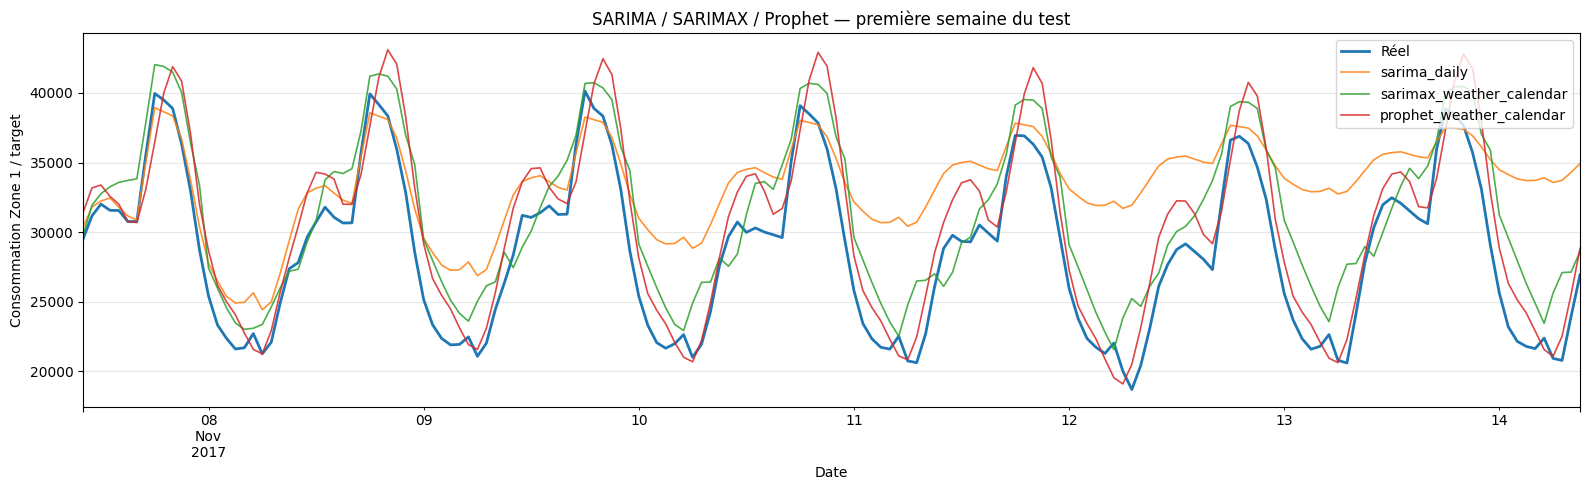

Figure sauvegardée : C:\Users\Badr\UB\0_Inbox\00-projects-code\dm-pfm-project\smart-city-energy-forecasting-tetouan\results\figures\sarima_prophet_forecast_test_week.png


In [43]:
plot_df = predictions.dropna().iloc[: 24 * 7].copy()

fig, ax = plt.subplots(figsize=(16, 5))

plot_df["y_true"].plot(
    ax=ax,
    linewidth=2,
    label="Réel",
)

for col in predictions.columns:
    if col != "y_true" and col in plot_df.columns:
        plot_df[col].plot(
            ax=ax,
            linewidth=1.2,
            alpha=0.85,
            label=col,
        )

ax.set_title("SARIMA / SARIMAX / Prophet — première semaine du test")
ax.set_xlabel("Date")
ax.set_ylabel("Consommation Zone 1 / target")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SARIMA_PROPHET_FIG_PATH, dpi=150)
plt.show()

print(f"Figure sauvegardée : {SARIMA_PROPHET_FIG_PATH}")

## 13. Visualisation — test complet

Cette figure donne une vue globale sur toute la période de test.
Elle permet d'identifier les dérives éventuelles des modèles sur un horizon long.

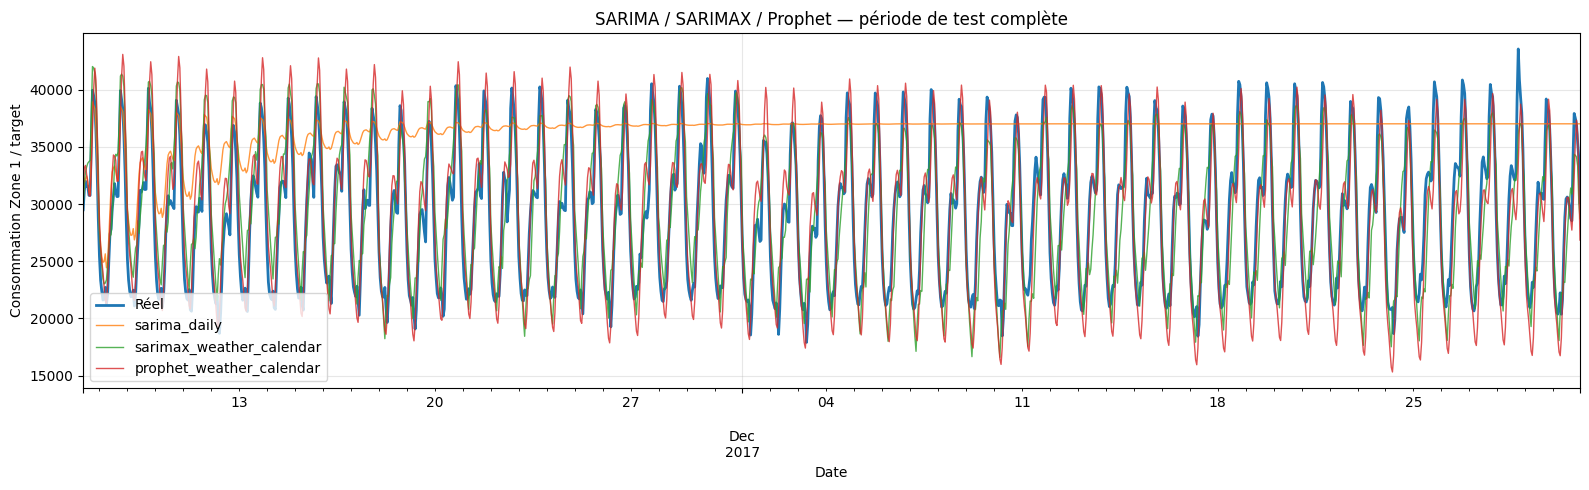

Figure sauvegardée : C:\Users\Badr\UB\0_Inbox\00-projects-code\dm-pfm-project\smart-city-energy-forecasting-tetouan\results\figures\sarima_prophet_forecast_full_test.png


In [44]:
fig, ax = plt.subplots(figsize=(16, 5))

predictions["y_true"].plot(
    ax=ax,
    linewidth=2,
    label="Réel",
)

for col in predictions.columns:
    if col != "y_true":
        predictions[col].plot(
            ax=ax,
            linewidth=1.0,
            alpha=0.8,
            label=col,
        )

ax.set_title("SARIMA / SARIMAX / Prophet — période de test complète")
ax.set_xlabel("Date")
ax.set_ylabel("Consommation Zone 1 / target")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SARIMA_PROPHET_FULL_FIG_PATH, dpi=150)
plt.show()

print(f"Figure sauvegardée : {SARIMA_PROPHET_FULL_FIG_PATH}")

## 14. Analyse des erreurs par heure

La moyenne globale peut cacher des faiblesses pendant les heures critiques.

Cette analyse calcule l'erreur absolue moyenne par heure de la journée.

,hour,MAE_by_hour,model
0,0,10411.973956,sarima_daily
1,1,12592.074265,sarima_daily
2,2,13777.895193,sarima_daily
3,3,14390.674570,sarima_daily
4,4,14493.229159,sarima_daily


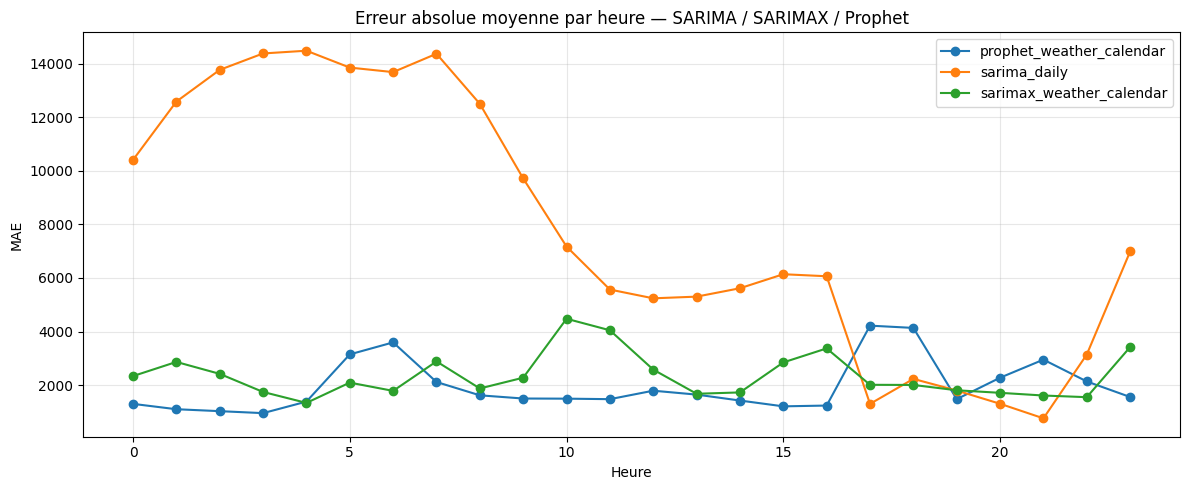

In [45]:
error_by_hour_rows = []

for model_col in [col for col in predictions.columns if col != "y_true"]:
    temp = predictions[["y_true", model_col]].dropna().copy()
    temp["hour"] = temp.index.hour
    temp["abs_error"] = (temp["y_true"] - temp[model_col]).abs()

    grouped = (
        temp.groupby("hour")["abs_error"]
        .mean()
        .reset_index()
        .rename(columns={"abs_error": "MAE_by_hour"})
    )

    grouped["model"] = model_col
    error_by_hour_rows.append(grouped)

error_by_hour = pd.concat(error_by_hour_rows, axis=0, ignore_index=True)

display(error_by_hour.head())

fig, ax = plt.subplots(figsize=(12, 5))

for model_name, group in error_by_hour.groupby("model"):
    group.plot(
        x="hour",
        y="MAE_by_hour",
        ax=ax,
        marker="o",
        label=model_name,
    )

ax.set_title("Erreur absolue moyenne par heure — SARIMA / SARIMAX / Prophet")
ax.set_xlabel("Heure")
ax.set_ylabel("MAE")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## 15. Interprétation automatique rapide

Cette cellule identifie le meilleur modèle de cette phase selon le MAPE.

In [46]:
best_model = comparison_metrics.iloc[0]

print("Meilleur modèle selon le MAPE :")
print(f"- Modèle : {best_model['model']}")
print(f"- Famille : {best_model['model_family']}")
print(f"- MAE   : {best_model['MAE']:.2f}")
print(f"- RMSE  : {best_model['RMSE']:.2f}")
print(f"- MAPE  : {best_model['MAPE']:.2f}%")
print(f"- R2    : {best_model['R2']:.4f}")

print("\nInterprétation :")

if "naive" in str(best_model["model"]):
    print(
        "La meilleure méthode reste une baseline naïve. "
        "Cela signifie que la saisonnalité historique, notamment hebdomadaire, "
        "est très forte et difficile à dépasser avec des modèles statistiques globaux. "
        "Ce résultat n'est pas une erreur : il fixe un seuil exigeant pour les modèles ML."
    )
else:
    print(
        "Un modèle statistique ou Prophet dépasse les baselines naïves. "
        "Cela indique que les composantes saisonnières et/ou exogènes apportent "
        "une information supplémentaire utile par rapport à la simple répétition du passé."
    )

Meilleur modèle selon le MAPE :
- Modèle : naive_previous_week
- Famille : Naive baseline
- MAE   : 792.88
- RMSE  : 1098.38
- MAPE  : 2.78%
- R2    : 0.9665

Interprétation :
La meilleure méthode reste une baseline naïve. Cela signifie que la saisonnalité historique, notamment hebdomadaire, est très forte et difficile à dépasser avec des modèles statistiques globaux. Ce résultat n'est pas une erreur : il fixe un seuil exigeant pour les modèles ML.


SARIMA simple est conservé comme baseline statistique faible. Son R² négatif n’indique pas une erreur d’exécution, mais une incapacité de cette configuration à capturer la dynamique hebdomadaire dominante.

## 16. Synthèse pour le rapport final

Dans cette phase, trois modèles classiques ont été testés :

1. **SARIMA univarié** : modèle statistique basé uniquement sur l'historique de la cible.
2. **SARIMAX avec exogènes** : extension de SARIMA intégrant météo et variables calendaires.
3. **Prophet avec régresseurs** : modèle additif combinant tendance, saisonnalités, jours fériés et variables exogènes.

Ces modèles sont comparés aux baselines naïves du notebook 04. La baseline `naive_previous_week` constitue un seuil très fort, car la consommation électrique de Tétouan présente une saisonnalité hebdomadaire marquée.

Si SARIMA/SARIMAX/Prophet ne battent pas cette baseline, ce n'est pas forcément un échec. Cela signifie que la simple répétition de la même heure de la semaine précédente capture déjà une grande partie de la structure de la série. Les modèles ML tabulaires du notebook suivant, notamment Random Forest et XGBoost avec lags et rolling features, auront plus de chances de dépasser cette baseline grâce à leur capacité à exploiter les non-linéarités et les interactions.